In [20]:
from pycocotools.coco import COCO
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import skimage.io as io
import numpy as np

COCO_DATA_SPLIT = 'val2017' # train2017, val2017

coco_kp = COCO(f'data/COCO/annotations/person_keypoints_{COCO_DATA_SPLIT}.json')
coco_inst = COCO(f'data/COCO/annotations/instances_{COCO_DATA_SPLIT}.json')

loading annotations into memory...
Done (t=0.16s)
creating index...
index created!
loading annotations into memory...
Done (t=0.41s)
creating index...
index created!


## Plotting Functions

In [21]:
def plot_image(img_id):
    # Load image info
    img_info = coco_kp.loadImgs(img_id)[0]

    # Load person annotations (with keypoints)
    ann_ids_person = coco_kp.getAnnIds(imgIds=img_id, catIds=coco_kp.getCatIds(catNms=['person'])[0])
    anns_person = coco_kp.loadAnns(ann_ids_person)

    # Load bicycle annotations (with bounding boxes)
    ann_ids_bike = coco_inst.getAnnIds(imgIds=img_id, catIds=coco_inst.getCatIds(catNms=['bicycle'])[0])
    anns_bike = coco_inst.loadAnns(ann_ids_bike)

    # Load image from disk
    img_path = f"data/COCO/{COCO_DATA_SPLIT}/{img_info['file_name']}"
    image = io.imread(img_path)

    # Create plot
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    ax = plt.gca()

    # Draw bicycle bounding boxes
    for ann in anns_bike:
        x, y, w, h = ann['bbox']
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='blue', facecolor='none')
        ax.add_patch(rect)

    # Draw person bounding boxes
    for ann in anns_person:
        x, y, w, h = ann['bbox']
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='green', facecolor='none')
        ax.add_patch(rect)

    # Draw person keypoints
    for ann in anns_person:
        keypoints = ann['keypoints']
        for i in range(0, len(keypoints), 3):
            x, y, v = keypoints[i:i+3]
            if v > 0:  # v>0 means labeled (visible or not visible)
                plt.scatter(x, y, c='red', s=20)

    number_of_keypoint_annotations = sum(1 for ann in anns_person if ann['num_keypoints'] > 0)

    plt.axis('off')
    plt.title(f"Image ID: {img_id} — {len(anns_person)} person(s) ({number_of_keypoint_annotations} w/ keypoints), {len(anns_bike)} bicycle(s)")
    plt.show()

In [22]:
def plot_pair(pair):
    # Plot image highlighting a specific person-bicycle pair
    
    img_id, person_ann, bike_ann = pair
    
    # Load image info
    img_info = coco_kp.loadImgs(img_id)[0]

    # Load ALL person annotations (with keypoints)
    ann_ids_person = coco_kp.getAnnIds(imgIds=img_id, catIds=coco_kp.getCatIds(catNms=['person'])[0])
    anns_person = coco_kp.loadAnns(ann_ids_person)

    # Load ALL bicycle annotations (with bounding boxes)
    ann_ids_bike = coco_inst.getAnnIds(imgIds=img_id, catIds=coco_inst.getCatIds(catNms=['bicycle'])[0])
    anns_bike = coco_inst.loadAnns(ann_ids_bike)

    # Load image from disk
    img_path = f"data/COCO/{COCO_DATA_SPLIT}/{img_info['file_name']}"
    image = io.imread(img_path)

    # Create plot
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    ax = plt.gca()

    # Draw ALL bicycle bounding boxes (dim for non-highlighted)
    for ann in anns_bike:
        x, y, w, h = ann['bbox']
        if ann['id'] == bike_ann['id']:
            # Highlight the selected bicycle
            rect = patches.Rectangle((x, y), w, h, linewidth=3, edgecolor='blue', facecolor='none')
        else:
            # Dim other bicycles
            rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='lightblue', facecolor='none', alpha=0.3)
        ax.add_patch(rect)

    # Draw ALL person bounding boxes (dim for non-highlighted)
    for ann in anns_person:
        x, y, w, h = ann['bbox']
        if ann['id'] == person_ann['id']:
            # Highlight the selected person
            rect = patches.Rectangle((x, y), w, h, linewidth=3, edgecolor='green', facecolor='none')
        else:
            # Dim other persons
            rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='lightgreen', facecolor='none', alpha=0.3)
        ax.add_patch(rect)

    # Draw keypoints ONLY for the highlighted person
    keypoints = person_ann['keypoints']
    for i in range(0, len(keypoints), 3):
        x, y, v = keypoints[i:i+3]
        if v > 0:  # v>0 means labeled (visible or not visible)
            plt.scatter(x, y, c='red', s=30, zorder=10)

    plt.axis('off')
    plt.title(f"Image ID: {img_id} — Highlighted pair (Person ID: {person_ann['id']}, Bicycle ID: {bike_ann['id']})")
    plt.show()


In [23]:
def plot_image_with_pairs(img_id, pairs_list):
    # Get pairs for this specific image from valid_pairs
    img_pairs = [(person_ann, bike_ann) for img, person_ann, bike_ann in pairs_list if img == img_id]
    
    # Load image info
    img_info = coco_kp.loadImgs(img_id)[0]

    # Load image from disk
    img_path = f"data/COCO/{COCO_DATA_SPLIT}/{img_info['file_name']}"
    image = io.imread(img_path)

    # Create plot
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    ax = plt.gca()

    # Draw only the valid pairs
    for person_ann, bike_ann in img_pairs:
        # Draw bicycle bounding box
        x, y, w, h = bike_ann['bbox']
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='blue', facecolor='none')
        ax.add_patch(rect)
        
        # Draw person bounding box
        x, y, w, h = person_ann['bbox']
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='green', facecolor='none')
        ax.add_patch(rect)
        
        # Draw person keypoints
        keypoints = person_ann['keypoints']
        for i in range(0, len(keypoints), 3):
            x, y, v = keypoints[i:i+3]
            if v > 0:
                plt.scatter(x, y, c='red', s=20)

    plt.axis('off')
    plt.title(f"Image ID: {img_id} — {len(img_pairs)} valid pair(s)")
    plt.show()

## Filter by Category

Find images that contain at least one person annotation and at least one bicycle annotation.

In [24]:
# Get category IDs
person_cat_id = coco_kp.getCatIds(catNms=['person'])[0]
bicycle_cat_id = coco_inst.getCatIds(catNms=['bicycle'])[0]

# Get image IDs
person_img_ids = set(coco_kp.getImgIds(catIds=[person_cat_id]))
bicycle_img_ids = set(coco_inst.getImgIds(catIds=[bicycle_cat_id]))

common_img_ids = list(person_img_ids & bicycle_img_ids)
print(f"Found {len(common_img_ids)} images with both person and bicycle.")

Found 122 images with both person and bicycle.


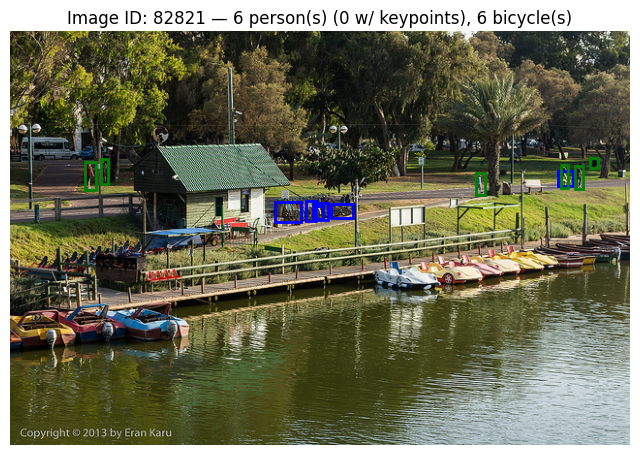

In [25]:
img_id = random.choice(common_img_ids)
plot_image(img_id)

## Filter by Keypoints

Filter for images with at least one person that has keypoints

In [26]:
img_ids_with_keypoints = []

for img_id in common_img_ids:
    ann_ids = coco_kp.getAnnIds(imgIds=img_id, catIds=person_cat_id)
    anns = coco_kp.loadAnns(ann_ids)
    
    # Check if any person annotation has keypoints
    if any(ann['num_keypoints'] > 0 for ann in anns):
        img_ids_with_keypoints.append(img_id)

print(f"Found {len(img_ids_with_keypoints)} images with person keypoints and bicycles.")

Found 103 images with person keypoints and bicycles.


## Filter by IoU

Filter for images where at least one person-bicycle pair has IoU > 0.1.

In [27]:
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0] + boxA[2], boxB[0] + boxB[2])
    yB = min(boxA[1] + boxA[3], boxB[1] + boxB[3])

    interW = max(0, xB - xA)
    interH = max(0, yB - yA)
    interArea = interW * interH

    boxAArea = boxA[2] * boxA[3]
    boxBArea = boxB[2] * boxB[3]
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

In [28]:
# Store valid (image_id, person_ann, bike_ann) tuples that pass all filters
iou_pairs = []

for img_id in img_ids_with_keypoints:
    # Get person annotations with keypoints
    ann_ids_person = coco_kp.getAnnIds(imgIds=img_id, catIds=person_cat_id)
    anns_person = coco_kp.loadAnns(ann_ids_person)
    anns_person = [ann for ann in anns_person if ann['num_keypoints'] > 0]
    
    # Get bicycle annotations
    ann_ids_bike = coco_inst.getAnnIds(imgIds=img_id, catIds=bicycle_cat_id)
    anns_bike = coco_inst.loadAnns(ann_ids_bike)
    
    # Check all person-bicycle pairs and store valid ones
    for person_ann in anns_person:
        for bike_ann in anns_bike:
            iou = compute_iou(person_ann['bbox'], bike_ann['bbox'])
            if iou > 0.1:
                iou_pairs.append((img_id, person_ann, bike_ann))

print(f"Found {len(iou_pairs)} person-bicycle pairs with IoU > 0.1.")
print(f"Across {len(set(pair[0] for pair in iou_pairs))} unique images.")

Found 85 person-bicycle pairs with IoU > 0.1.
Across 51 unique images.


## Filter by Position

Filter for images where person is positioned above/on the bicycle.

In [29]:
# Filter pairs where person is positioned above bicycle with x-axis alignment
person_above_bike_pairs = []

for img_id, person_ann, bike_ann in iou_pairs:
    px, py, pw, ph = person_ann['bbox']
    person_x_center = px + pw / 2
    person_y_center = py + ph / 2
    person_y_max = py + ph
    
    bx, by, bw, bh = bike_ann['bbox']
    bike_x_center = bx + bw / 2
    bike_y_center = by + bh / 2
    bike_y_min = by
    
    # Check if person is above bicycle and overlapping vertically
    vertical_check = person_y_center < bike_y_center and person_y_max > bike_y_min
    
    # Check x-axis alignment: centers should be reasonably close
    x_distance = abs(person_x_center - bike_x_center)
    max_allowed_distance = (pw + bw) / 4  # Allow some offset, roughly 25% of combined width
    horizontal_check = x_distance < max_allowed_distance
    
    if vertical_check and horizontal_check:
        person_above_bike_pairs.append((img_id, person_ann, bike_ann))

print(f"Found {len(person_above_bike_pairs)} pairs with person positioned above bicycle (with x-alignment).")
print(f"Across {len(set(pair[0] for pair in person_above_bike_pairs))} unique images.")

Found 63 pairs with person positioned above bicycle (with x-alignment).
Across 45 unique images.


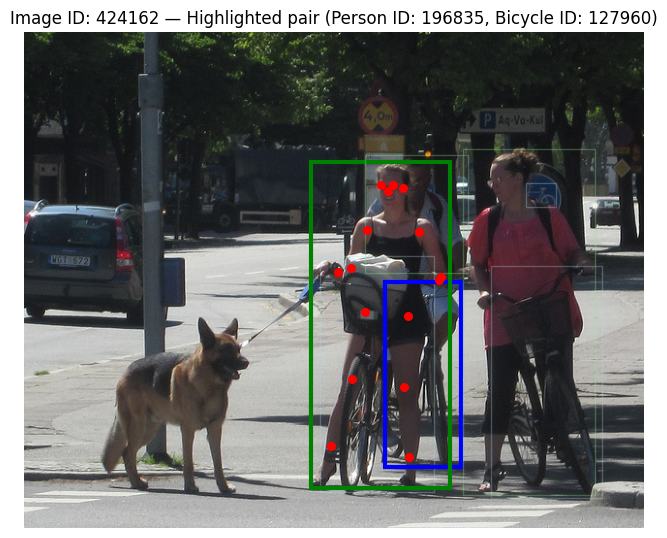

In [30]:
plot_pair(random.choice(person_above_bike_pairs))

In [31]:
# plot_image_with_pairs(483165, person_above_bike_pairs)

In [32]:
# plot_image_with_pairs(174304, person_above_bike_pairs)

## Filter by Keypoint Visibility

In [33]:
# Filter for bike-fitting relevant keypoints and require all major regions
highquality_pose_pairs = []

for img_id, person_ann, bike_ann in person_above_bike_pairs:
    keypoints = person_ann['keypoints']
    
    # Minimum keypoint count
    if person_ann['num_keypoints'] < 10:
        continue
    
    # Key body parts for bike fitting: shoulders, hips, knees, ankles
    has_shoulder = keypoints[5*3+2] > 0 or keypoints[6*3+2] > 0   # L/R shoulders
    has_hip      = keypoints[11*3+2] > 0 or keypoints[12*3+2] > 0  # L/R hips
    has_knee     = keypoints[13*3+2] > 0 or keypoints[14*3+2] > 0  # L/R knees
    has_ankle    = keypoints[15*3+2] > 0 or keypoints[16*3+2] > 0  # L/R ankles
    
    # Require ALL 4 body regions
    if not (has_shoulder and has_hip and has_knee and has_ankle):
        continue
    
    highquality_pose_pairs.append((img_id, person_ann, bike_ann))

print(f"Found {len(highquality_pose_pairs)} pairs with all bike-fitting keypoints.")
print(f"Across {len(set(pair[0] for pair in highquality_pose_pairs))} unique images.")

Found 53 pairs with all bike-fitting keypoints.
Across 39 unique images.


## Metrics Calculation

In [34]:
def calculate_scale_metrics(pairs):
    # Calculate how much of the frame the cyclist occupies
    scale_ratios = []
    
    for img_id, person_ann, bike_ann in pairs:
        img_info = coco_kp.loadImgs(img_id)[0]
        img_area = img_info['width'] * img_info['height']
        
        person_bbox = person_ann['bbox']
        person_area = person_bbox[2] * person_bbox[3]
        
        scale_ratio = person_area / img_area
        scale_ratios.append(scale_ratio)
    
    return scale_ratios

coco_scales = calculate_scale_metrics(highquality_pose_pairs)
print(f"COCO cyclists: {np.mean(coco_scales)*100:.1f}% of frame")


COCO cyclists: 8.2% of frame


In [35]:
def calculate_joint_lengths(person_ann):
    # Calculate average length of major body segments in pixels
    keypoints = person_ann['keypoints']
    
    # Define major joints for cycling (shoulder-elbow, elbow-wrist, hip-knee, knee-ankle)
    joint_pairs = [
        (5, 7),   # left shoulder-elbow
        (6, 8),   # right shoulder-elbow
        (7, 9),   # left elbow-wrist
        (8, 10),  # right elbow-wrist
        (11, 13), # left hip-knee
        (12, 14), # right hip-knee
        (13, 15), # left knee-ankle
        (14, 16), # right knee-ankle
    ]
    
    lengths = []
    for kp1_idx, kp2_idx in joint_pairs:
        kp1 = keypoints[kp1_idx*3:kp1_idx*3+3]
        kp2 = keypoints[kp2_idx*3:kp2_idx*3+3]
        
        if kp1[2] > 0 and kp2[2] > 0:  # Both visible
            length = np.sqrt((kp1[0] - kp2[0])**2 + (kp1[1] - kp2[1])**2)
            lengths.append(length)
    
    return np.mean(lengths) if lengths else None

coco_joint_lengths = [calculate_joint_lengths(pair[1]) for pair in highquality_pose_pairs]
coco_joint_lengths = [l for l in coco_joint_lengths if l is not None]

print(f"COCO average joint length: {np.mean(coco_joint_lengths):.1f} pixels")

COCO average joint length: 38.1 pixels
